# 10 – Puolueiden tunnusomaiset sanat luokittelijan painoista

**Tehtävä:** projektisuunnitelman kuva 3. Mitkä sanat ja sanaparit erottavat kunkin puolueen muista kullakin kaudella? Vastaus luetaan luokittelijan painoista (*coefficients*).

**Syöte:** `Data/processed/counts.npz`, `counts_index.parquet` ja `vocab.txt` (muistio 04)
**Tulokset:**
- `results/sanat_puolueittain.csv`: 40 painavinta fraasia per puolue per kausi
- `reports/figures/sanat_puolueittain.png`: suomenkielinen kuva (englanninkielinen versio muistiossa 08)

## Menetelmä

Malli on sama kuin muistiossa 05: TF-IDF ja multinomiaalinen logistinen regressio, C = 2. Muistio 05 ei tallenna painoja, koska se opettaa satoja malleja ristiinvalidoinnissa. Tässä opetetaan kullekin kaudelle 10 mallia koko kauden aineistolla:

1. Arvotaan 80 % kunkin puolueen edustajista (kuten muistion 05 toistoissa).
2. Heidän puheistaan arvotaan 700 puhetta per puolue. Luku on sama kaikille puolueille ja kausille, jotta painot ovat vertailukelpoisia. Pienin ryhmä on KD 2023–27 (717 puhetta).
3. Opetetaan malli ja tallennetaan painot.

Fraasin **paino** puolueelle on 10 mallin painojen keskiarvo. Positiivinen paino tarkoittaa, että fraasi nostaa todennäköisyyttä, että puhuja on tästä puolueesta eikä jostain muusta. **Pysyvyys** (*stability*) on osuus malleista, joissa fraasi on puolueen 15 painavimman joukossa. Se kertoo, riippuuko tulos siitä, mitkä edustajat otokseen osuivat.

**Suurimman käyttäjän osuus** on se osuus puolueen kaikista fraasin esiintymistä kaudella, joka tulee yhdeltä edustajalta. Jos osuus on yli puolet, sana on lähinnä yhden edustajan maneeri tai aihe eikä puolueen yhteistä kieltä. Kuvaan otetaan vain fraasit, joissa osuus on enintään puolet; taulukossa näkyvät kaikki.

## Tulkinnan rajoitukset

- Fraasit ovat **vartaloita** (*stems*, muistio 02): *leikkauks* = leikkaus, leikkauksen, leikkauksia. Sanapari näytetään välilyönnillä: `koko suome` = *koko Suomen*.
- Paino on **ehdollinen** muille sanoille: se kertoo fraasin lisäarvon, kun muut fraasit ovat jo mallissa. Kaksi lähes aina yhdessä esiintyvää sanaa voivat jakaa painon keskenään.
- Painava sana voi olla **tyylisana** eikä aihe (ks. tulkinta).
- Siivous (muistio 02) poistaa puolueiden nimet, mutta sanastoon jäävät puolueisiin viittaavat yleissanat *vasemmisto* ja *vihreä*. Ne tarkistetaan lopussa.

In [1]:
import sys
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, "../src")
import config

KANSIO = "../Data/processed/"
TULOKSET = "../results/"
KUVAT = "../reports/figures/"
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]
SIEMENET = {"2015-2019": 100, "2019-2023": 101, "2023-2027": 102}
PUOLUEET = list(config.MAIN_PARTIES)

# Asetukset
MIN_FRAASEJA = 20      # sama rajaus kuin muistiossa 05
N_PUHEITA = 700        # puheita per puolue per malli
EDUSTAJA_OSUUS = 0.8
C = 2.0
MALLEJA = 10           # malleja per kausi
N_SANOJA = 40          # tallennettavat fraasit per puolue
TOP = 15               # pysyvyys: osuus malleista, joissa fraasi on TOP painavimman joukossa

In [2]:
X_kaikki = sp.load_npz(KANSIO + "counts.npz").tocsr()
indeksi = pd.read_parquet(KANSIO + "counts_index.parquet")
with open(KANSIO + "vocab.txt", encoding="utf-8") as f:
    sanasto = np.array([rivi.strip() for rivi in f if rivi.strip()])
fraaseja = np.asarray(X_kaikki.sum(axis=1)).ravel()
print("Matriisi:", X_kaikki.shape, " sanasto:", len(sanasto))

rivit = indeksi["party"].isin(PUOLUEET).to_numpy() & (fraaseja >= MIN_FRAASEJA)
indeksi[rivit].groupby(["term", "party"]).size().unstack()[PUOLUEET]

Matriisi: (130965, 26203)  sanasto: 26203


party,VAS,SDP,VIHR,KESK,RKP,KD,KOK,PS
term,,,,,,,,
2015-2019,3963,10513,4022,11113,1147,2441,7531,7251
2019-2023,2761,8092,3442,7710,907,1933,8527,9304
2023-2027,2534,9924,2757,5065,615,717,7844,8363


## Funktiot

`sovita_painot` opettaa yhden kauden 10 mallia ja palauttaa painojen keskiarvon sekä jokaisen fraasin top 15 -osumien määrän. `suurin_kayttaja` laskee, kuinka suuri osa puolueen fraasin käytöstä tulee yhdeltä edustajalta.

In [3]:
def sovita_painot(kausi):
    rng = np.random.default_rng(SIEMENET[kausi])
    rivit = (indeksi["term"] == kausi).to_numpy() & indeksi["party"].isin(PUOLUEET).to_numpy() & (fraaseja >= MIN_FRAASEJA)
    puheet = indeksi[rivit].reset_index(drop=True)
    X = X_kaikki[rivit]

    painot = []
    osumat = {puolue: Counter() for puolue in PUOLUEET}
    for malli in range(MALLEJA):
        valitut_rivit = []
        for puolue in PUOLUEET:
            edustajat = puheet.loc[puheet["party"] == puolue, "person_id"].unique()
            maara = max(2, int(round(EDUSTAJA_OSUUS * len(edustajat))))
            valitut = rng.choice(edustajat, size=maara, replace=False)
            ehdokkaat = np.where((puheet["party"] == puolue).to_numpy() & puheet["person_id"].isin(valitut).to_numpy())[0]
            valitut_rivit.extend(rng.choice(ehdokkaat, size=min(N_PUHEITA, len(ehdokkaat)), replace=False))
        valitut_rivit = np.array(valitut_rivit)

        tfidf = TfidfTransformer(sublinear_tf=True).fit(X[valitut_rivit])
        luokittelija = LogisticRegression(C=C, max_iter=3000)
        luokittelija.fit(tfidf.transform(X[valitut_rivit]), puheet["party"].to_numpy()[valitut_rivit])
        W = pd.DataFrame(luokittelija.coef_, index=luokittelija.classes_)
        painot.append(luokittelija.coef_)
        for puolue in PUOLUEET:
            osumat[puolue].update(np.argsort(-W.loc[puolue].to_numpy())[:TOP])

    keskiarvo = pd.DataFrame(np.mean(painot, axis=0), index=sorted(PUOLUEET))   # painojen keskiarvo malleista; classes_ on aakkosjärjestyksessä
    return keskiarvo, osumat, puheet, X


def suurin_kayttaja(puheet, X, puolue, sarake):
    """Suurimman käyttäjän osuus puolueen kaikista fraasin esiintymistä."""
    rivit = (puheet["party"] == puolue).to_numpy()
    maarat = pd.Series(X[rivit][:, sarake].toarray().ravel(), index=puheet.loc[rivit, "person_id"].to_numpy())
    per_edustaja = maarat.groupby(level=0).sum()
    return per_edustaja.max() / per_edustaja.sum()

## Ajo

In [4]:
taulukko = []
for kausi in KAUDET:
    painot, osumat, puheet, X = sovita_painot(kausi)
    for puolue in PUOLUEET:
        painot_puolue = painot.loc[puolue].to_numpy()
        jarjestys = np.argsort(-painot_puolue)[:N_SANOJA]
        for sija, sarake in enumerate(jarjestys, start=1):
            taulukko.append({
                "term": kausi, "party": puolue, "rank": sija,
                "phrase": str(sanasto[sarake]).replace("_", " "),
                "weight": painot_puolue[sarake],
                "stability": osumat[puolue][sarake] / MALLEJA,
                "top_speaker_share": suurin_kayttaja(puheet, X, puolue, sarake),
            })
    print(kausi, "valmis")

sanat = pd.DataFrame(taulukko)
sanat.to_csv(TULOKSET + "sanat_puolueittain.csv", index=False)
sanat.head()

2015-2019 valmis
2019-2023 valmis
2023-2027 valmis


,term,party,rank,phrase,weight,stability,top_speaker_share
0,2015-2019,VAS,1,kuink,3.135940,1.0,0.425968
1,2015-2019,VAS,2,työttöm,2.032996,0.9,0.252137
2,2015-2019,VAS,3,mitenk,1.938346,0.8,0.457317
3,2015-2019,VAS,4,ongelm,1.875981,0.8,0.243885
4,2015-2019,VAS,5,pitä,1.793762,0.6,0.332039


## Taulukko: 12 painavinta fraasia

Sulkeissa oleva merkki: \* = pysyvyys alle 0,5 (fraasi putoaa top 15:stä yli puolessa malleista), † = yli puolet käytöstä yhdeltä edustajalta.

In [5]:
def merkitty(rivi):
    teksti = rivi["phrase"]
    if rivi["stability"] < 0.5:
        teksti += "*"
    if rivi["top_speaker_share"] > 0.5:
        teksti += "†"
    return teksti


sanat["merkitty"] = sanat.apply(merkitty, axis=1)
lista = sanat[sanat["rank"] <= 12].groupby(["party", "term"])["merkitty"].agg(", ".join).unstack()
pd.set_option("display.max_colwidth", None)
lista.loc[PUOLUEET]

term,2015-2019,2019-2023,2023-2027
party,,,
VAS,"kuink, työttöm, mitenk, ongelm, pitä, pako, täytyy sano†, työntekijö, tarkoit, eli*, minister, kaut*","työntekijö, vasemmisto, kuink, koulutuks, työnantaj, ihmist, erit, toimeentulo, pienitulois, työttömyysturv, työttöm*, voito*","leikkauks, pienitulois, työntekijö, sosiaaliturvaleikkauks, leika, politiik, pääminister, leikkaat, asem*, ydinas*†, vanhuspalvelu*, hallituspuolue*"
SDP,"tääl, hallituspuolue, eläkkeensaaj†, minister, eduskun, siis, kyl*, ihmis, valiokun*, puole*, tiete*, tak*","kysymys, myösk, keskustelu, ihmis, kokonaisuud, vuoks, palvelu*, eduskun, tiete, osa*, iso*, sosiaal terveydenhuolo*","palkansaaj, työeläm, sit, pääminister, tääl, aika, leikkauks*, työntekij, työntekijö, miljoon*, työnantaj, pitäi*"
VIHR,"mite, ympäristövaliokun†, kaik, ihmis, ihmist*, kute, koulutuks, tahdo†, ilmastonmuutoks, ympäristö, vihreä*, leikkauks*","tärkeä, kute, ihmis, keino, tosia, myös, luono, tietyst, varmist*, tot kai, ilmastonmuutoks, yks","hallituks, luono, ajattel, hallitus, tode, ilmastotoim, päästöj, keino, leikkauks, ympäristö, ilmasto, pitäi*"
KESK,"erit, as, toiseks†, osa, jatko, pysty, eteenp, mets, pitä*, vaalikaud, myösk*, tot*","aiva, pitä, tule, erit, koko suome, vaik, kasvu, maataloud, suomalais*, maakun, tot, kyl","itäis suome†, vaalikaud, itäis, kyl, pitä, kysy, maakun, siel, pohjois, kunnioitetu†, lähipalvelu*, kannatai*"
RKP,"hallitus, vaasa, eduskuntaryhm, mite, ehk, tiete, ruots, luke, miele, pitäi, vars, myösk","oikeusministeriö†, tiete, elik†, ehk, yrit†, varm, poht†, tasa†, äärimmäis†, oleel†, toki*†, mite*","myösk†, koulu, panost, tiete†, tosi, tärkeä, panostuks, oppimis†, as*, luoda, peruskoulu†, varhaiskasvatuks†"
KD,"sit, tode, kyl, olis†, tääl, ikä, kohd†, voisi sano†, ajattel†, eduskuntaryhm*, potil, näit†","tode, kyl, sit†, ajattel, eduskuntaryhm†, kohd†, näit†, toisa†, voisi sano†, halunu†, terveydenhuolo, miele†","elik†, nimenomais†, nimenom, tuottaj†, hamas, nost, oppositio*, nost es†, ajatel, myösk sit†, maataloud†, myösk*†"
KOK,"eli, tietyst, työtä, myösk, työn, pitä, ratkaisu, esimerk*, pyri*, usko*, ensin*, teem*","pääminister, hallituks, minister, hallituspuolue, kysy, lakialoit, terapiataku, asia*, siis, valtiovarainminister*, pitäi*, sivistysvaliokun*†","uudistuks, miljard, teem, eli, tietyst, työtä, töitä, taas vastaav†, vahvist, talous*, ensin*, turvallisuus*†"
PS,"lakialoit, tosia, maahanmuuto, siel, kans, henkilö, täytyy*, oppositio, aina, site*, kute*, muun*","raha, kans, maahanmuuto, jopa, oikeast, ongelm, edes, siel, pitäi, henkilö, aiot, kuite*","rikoks, maahanmuuttopolitiik, kunnioitetu, oppositio, maahanmuuto, maas, vasem, vasemmisto, kute*, veronmaksaj, poliis*, äärettöm*"


## Kuva 3

Rivit ovat puolueita ja sarakkeet kausia. Kuvassa on kunkin puolueen 10 painavinta fraasia niistä, joiden käytöstä korkeintaan puolet tulee yhdeltä edustajalta. Palkki on fraasin paino; vaalea palkki = pysyvyys alle 0,5.

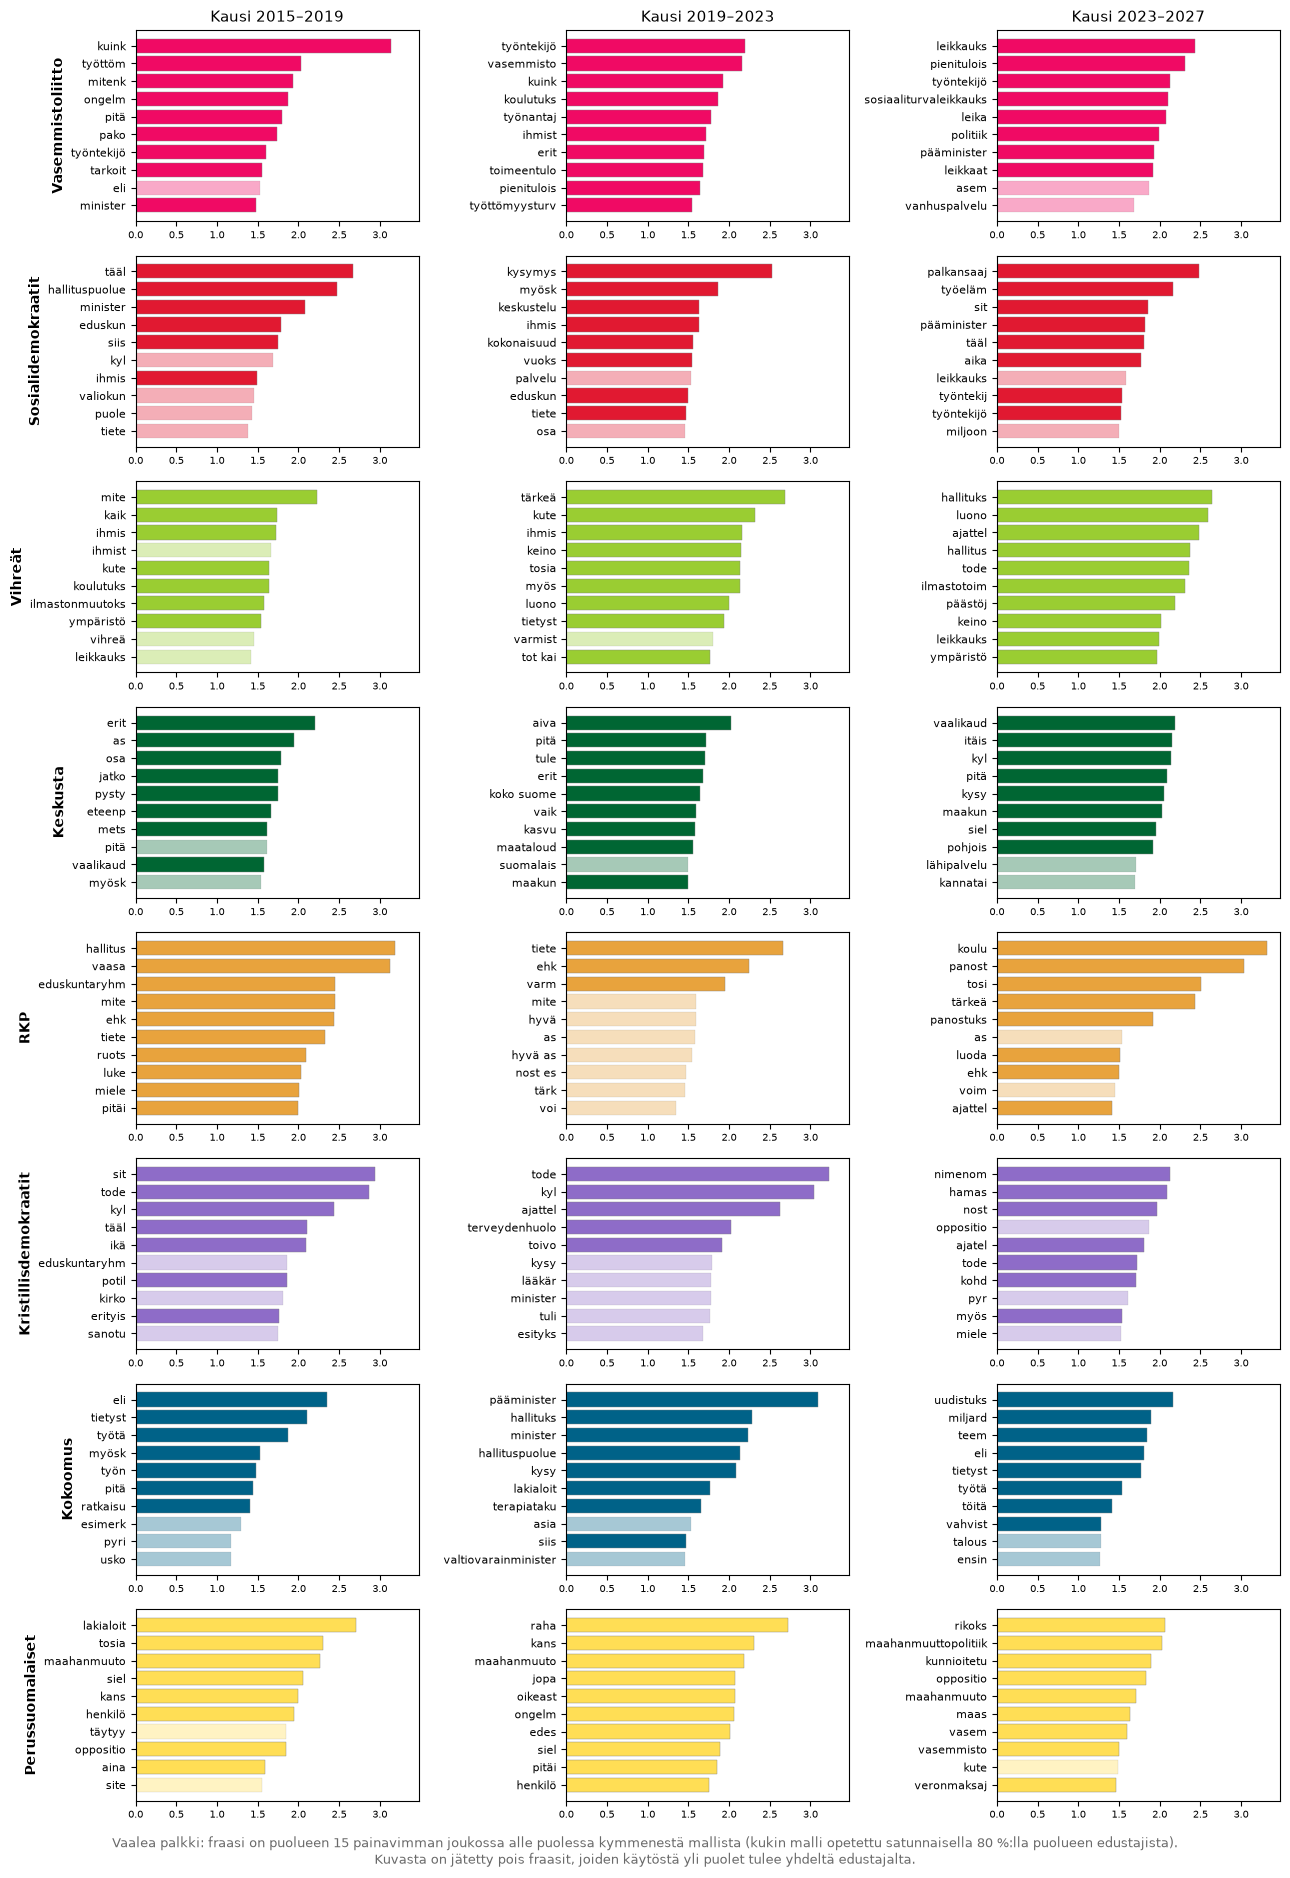

In [6]:
def piirra_sanat(sanat, nimet, otsikot, selite, tiedosto, n=10):
    fig, ax = plt.subplots(len(PUOLUEET), len(KAUDET), figsize=(13, 2.3 * len(PUOLUEET)))
    suurin = sanat[sanat["top_speaker_share"] <= 0.5]["weight"].max()
    for i, puolue in enumerate(PUOLUEET):
        for j, kausi in enumerate(KAUDET):
            osa = sanat[(sanat["party"] == puolue) & (sanat["term"] == kausi) & (sanat["top_speaker_share"] <= 0.5)].head(n)
            y = np.arange(len(osa))[::-1]
            for yy, (_, rivi) in zip(y, osa.iterrows()):
                ax[i, j].barh(yy, rivi["weight"], color=config.PARTY_COLORS[puolue],
                              alpha=1.0 if rivi["stability"] >= 0.5 else 0.35,
                              edgecolor="grey", linewidth=0.3)
            ax[i, j].set_yticks(y)
            ax[i, j].set_yticklabels(osa["phrase"], fontsize=8)
            ax[i, j].set_xlim(0, suurin * 1.05)
            ax[i, j].tick_params(axis="x", labelsize=7)
            if i == 0:
                ax[i, j].set_title(otsikot[j], fontsize=11)
            if j == 0:
                ax[i, j].set_ylabel(nimet[puolue], fontsize=10, fontweight="bold")
    fig.tight_layout()
    fig.text(0.5, 0, selite, ha="center", va="top", fontsize=9, color="dimgray")
    fig.savefig(tiedosto, dpi=150, bbox_inches="tight")
    plt.show()


SELITE = ("Vaalea palkki: fraasi on puolueen 15 painavimman joukossa alle puolessa kymmenestä mallista "
          "(kukin malli opetettu satunnaisella 80 %:lla puolueen edustajista).\n"
          "Kuvasta on jätetty pois fraasit, joiden käytöstä yli puolet tulee yhdeltä edustajalta.")
piirra_sanat(sanat, config.PARTY_NAMES_FI, ["Kausi " + k.replace("-", "–") for k in KAUDET], SELITE,
             KUVAT + "sanat_puolueittain.png")

## Vuotojen tarkistus

Tarkistetaan, onko listoilla puolueiden nimiä, ruotsin sanoja tai edustajien nimiä. Puolueen nimi toisen puolueen listalla (esim. PS:n *sosiaalidemokraat*) ei ole vuoto vaan puhe toisesta puolueesta. Oman puolueen nimi on vuoto: se kertoo puolueen suoraan.

In [7]:
# vartalon alku; "keskust" ja "rkp" vain tarkkana osumana, koska esim. "keskustelu" alkaa samoin
nimen_alut = ["sosiaalidemokraat", "demari", "vasemmisto", "vihre", "kokoomu", "perussuomalai", "kristillis",
              "ruotsalai", "sinis"]
nimet_tarkka = ["keskust", "rkp"]
with open("../src/stopwords_sv.txt", encoding="utf-8") as f:
    ruotsi = {rivi.strip() for rivi in f}

epailyttavat = []
for _, rivi in sanat.iterrows():
    osat = rivi["phrase"].split()
    if any(osa.startswith(nimi) for osa in osat for nimi in nimen_alut) or any(osa in nimet_tarkka for osa in osat):
        epailyttavat.append((rivi["term"], rivi["party"], rivi["rank"], rivi["phrase"], "puolueen nimi"))
    elif any(osa in ruotsi for osa in osat):
        epailyttavat.append((rivi["term"], rivi["party"], rivi["rank"], rivi["phrase"], "ruotsi"))
pd.DataFrame(epailyttavat, columns=["kausi", "puolue", "sija", "fraasi", "syy"]).query("sija <= 15")

,kausi,puolue,sija,fraasi,syy
1,2015-2019,VIHR,11,vihreä,puolueen nimi
2,2015-2019,RKP,11,vars,ruotsi
3,2015-2019,PS,13,sin,ruotsi
4,2019-2023,VAS,2,vasemmisto,puolueen nimi
9,2023-2027,PS,8,vasemmisto,puolueen nimi


**Tulos:** listoilla (15 painavinta) on omaan puolueeseen viittaava sana kahdesti: VIHR *vihreä* (2015–19, sija 11) ja VAS *vasemmisto* (2019–23, sija 2). Tämä on pieni vuoto: malli tunnistaa puheen osin siitä, että puhuja mainitsee oman ryhmänsä. Ajo ilman tyylisanoja poistaa myös nämä sanat, ja polarisaatio on siinä lähes sama (muistio 05, ajo 5), joten vaikutus on pieni. PS:n listalla *vasemmisto* (2023–27, sija 8) ei ole vuotoa vaan puhetta oppositiosta. *vars* (varsinkin) ja *sin* (sinne, sinä) ovat suomen vartaloita, jotka sattuvat olemaan ruotsin täytesanoja.

## Tulkinta

**1. Aiheet ovat tunnistettavia ja pysyviä.** PS: maahanmuutto joka kaudella ja *kansa* kahdella ensimmäisellä, 2023–27 lisäksi rikokset ja veronmaksajat. VIHR: ilmasto, luonto ja päästöt. KESK: metsät, maatalous, maakunnat ja Itä-Suomi. VAS: työntekijät ja pienituloiset, 2023–27 leikkaukset. SDP 2023–27: palkansaajat ja työelämä. KOK: työ, talous ja uudistukset.

**2. Hallitusasema näkyy.** Oppositio puhuu hallituksesta ja pääministeristä (SDP 2015–19, KOK 2019–23, vasemmisto-vihreät 2023–27). Hallitukseen noussut PS puhuu 2023–27 oppositiosta ja vasemmistosta.

**3. Tyylisanat ovat painavia yksittäisinä sanoina** (*kyl* = kyllä, *sit* = sitten, *tääl* = täällä, *tode* = todeta). Ne ovat yleiskielisiä sanoja, joita NLTK:n täytesanalistassa ei ole, eivät murretta. Erottuvuus ei silti riipu niistä: ilman niitä polarisaatio on lähes sama (muistio 05, ajo 5).

**4. Pienissä puolueissa yksi edustaja voi hallita sanalistaa.** RKP:llä ja KD:llä moni kärkisana tulee pääosin yhdeltä edustajalta (†), esim. KD 2023–27 *nimenomais* (99 %). Siksi kuvassa näytetään vain sanat, joita käyttää useampi edustaja. Ristiinvalidointi on tehty edustajittain, joten tämä ei paisuta muistion 05 tuloksia.

Kuva on havainnollistus, ei itsenäinen tulos.